# 🍽️ KPT Prediction - ASIF System Demo

**Kitchen Prep Time (KPT) Prediction: Signal Redesign + De-noising + Live Rush Detection + Capacity-Aware Forecast**

This notebook demonstrates the full end-to-end workflow of the ASIF system:
1. Generate synthetic restaurant order data
2. Apply signal engineering (smoothing, anomaly detection, LRI)
3. Train ML forecast models (raw vs engineered features)
4. Run simulation comparing Baseline / ML-Only / ASIF
5. Visualise improvements


In [1]:
import sys, os
sys.path.insert(0, '../src')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

In [3]:
matplotlib.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded')

Libraries loaded


## 1. Generate Synthetic Dataset

In [4]:
from synthetic_data import generate_all_restaurants

DATA_PATH = '../data/synthetic_orders.csv'

if not os.path.exists(DATA_PATH):
    df_raw = generate_all_restaurants(n_restaurants=30, n_days=30, output_path=DATA_PATH)
else:
    df_raw = pd.read_csv(DATA_PATH)
    df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
    print(f'Loaded existing dataset: {df_raw.shape}')

df_raw.head()

Generating data for 30 restaurants over 30 days...
  ✓ Restaurant 10/30 done
  ✓ Restaurant 20/30 done
  ✓ Restaurant 30/30 done

✅ Dataset saved → ../data/synthetic_orders.csv
   Shape : (218594, 10)
   Date range: 2024-01-01 09:00:00 → 2024-01-30 23:59:00


,timestamp,restaurant_id,zomato_orders_per_min,promo_flag,weather_effect,local_event_flag,dine_in_load_proxy,sudden_rush_spike,true_prep_time,observed_prep_time
0,2024-01-01 09:00:00,3,4.230,1,1,0,0.264,0,25.23,27.55
1,2024-01-01 09:03:00,1,1.841,0,1,0,0.338,0,23.90,22.81
2,2024-01-01 09:05:00,11,1.581,0,0,0,0.384,0,15.32,12.99
3,2024-01-01 09:05:00,22,2.158,0,0,0,0.269,0,20.49,15.90
4,2024-01-01 09:07:00,15,3.207,0,1,1,0.329,0,23.02,24.95


In [5]:
# Dataset overview
print(f'Total orders      : {len(df_raw):,}')
print(f'Restaurants       : {df_raw["restaurant_id"].nunique()}')
print(f'Date range        : {df_raw["timestamp"].min().date()} → {df_raw["timestamp"].max().date()}')
print(f'Rush spikes       : {df_raw["sudden_rush_spike"].sum():,} ({100*df_raw["sudden_rush_spike"].mean():.1f}%)')
print(f'Promo orders      : {df_raw["promo_flag"].sum():,}')
print()
df_raw[['true_prep_time','observed_prep_time','zomato_orders_per_min']].describe().round(2)

Total orders      : 218,594
Restaurants       : 30
Date range        : 2024-01-01 → 2024-01-30
Rush spikes       : 19,532 (8.9%)
Promo orders      : 47,696



,true_prep_time,observed_prep_time,zomato_orders_per_min
count,218594.00,218594.00,218594.00
mean,24.15,24.87,6.27
std,3.97,6.05,1.52
min,9.17,1.45,0.48
25%,21.44,20.83,5.43
50%,24.04,24.26,6.48
75%,26.74,28.07,7.25
max,44.40,57.00,10.90


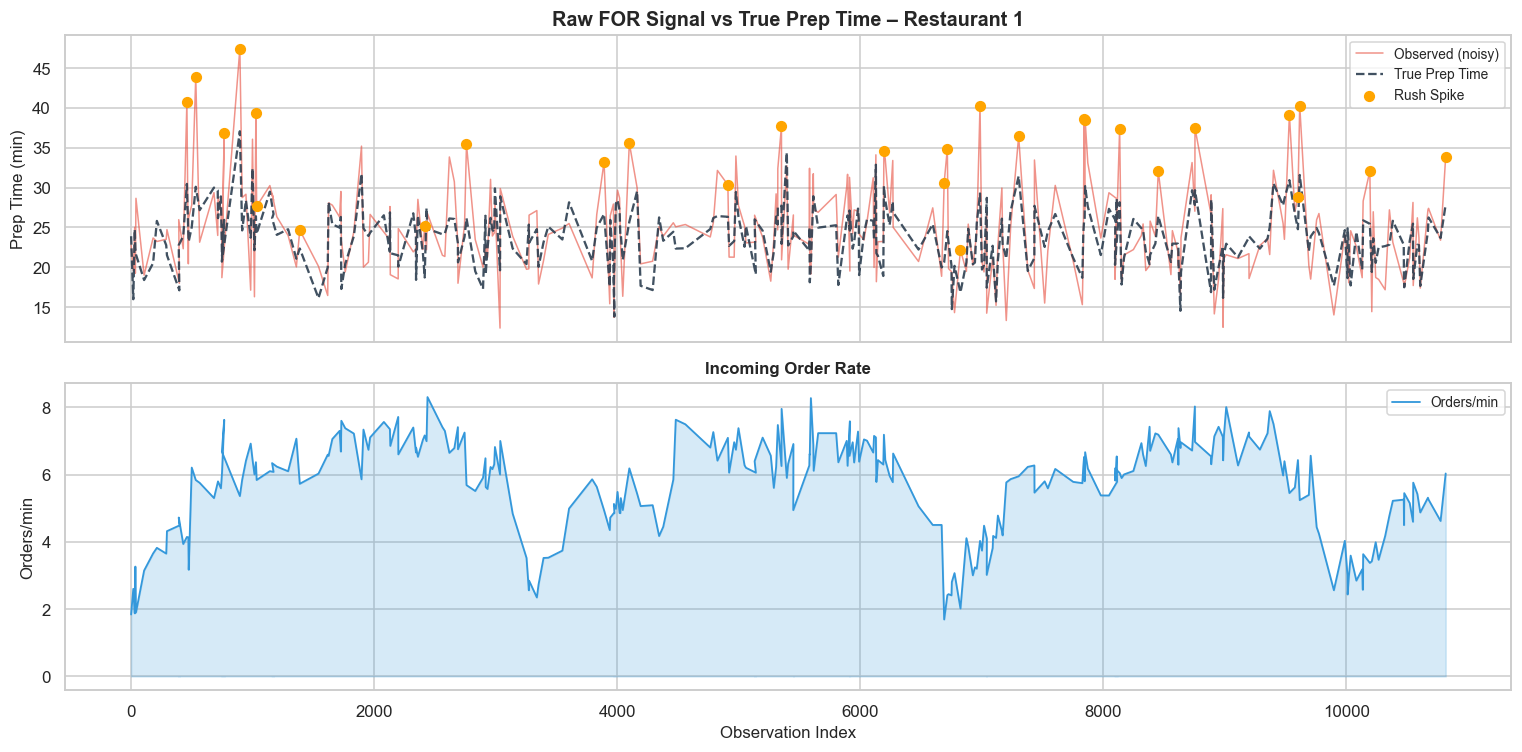

In [6]:
# Visualise raw signal noise
sample = df_raw[df_raw['restaurant_id'] == 1].sort_values('timestamp').head(300)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(sample.index, sample['observed_prep_time'], alpha=0.6, color='#e74c3c', label='Observed (noisy)', lw=1)
ax1.plot(sample.index, sample['true_prep_time'], alpha=0.9, color='#2c3e50', label='True Prep Time', lw=1.5, ls='--')
ax1.scatter(sample[sample['sudden_rush_spike']==1].index,
            sample[sample['sudden_rush_spike']==1]['observed_prep_time'],
            color='orange', s=40, zorder=5, label='Rush Spike')
ax1.set_ylabel('Prep Time (min)', fontsize=11)
ax1.set_title('Raw FOR Signal vs True Prep Time – Restaurant 1', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

ax2.plot(sample.index, sample['zomato_orders_per_min'], color='#3498db', lw=1.2, label='Orders/min')
ax2.fill_between(sample.index, sample['zomato_orders_per_min'], alpha=0.2, color='#3498db')
ax2.set_ylabel('Orders/min', fontsize=11)
ax2.set_xlabel('Observation Index', fontsize=11)
ax2.set_title('Incoming Order Rate', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2. Signal Engineering

In [7]:
from signal_engine import (
    smooth_signal,
    rolling_variance,
    detect_anomalies,
    compute_live_rush_index,
    capacity_adjusted_forecast,
    build_signal_features,
)

# Apply to full dataset
print('Building signal-engineered features...')
df = build_signal_features(df_raw)
new_cols = [c for c in df.columns if c not in df_raw.columns]
print(f'New features added: {new_cols}')
df[new_cols + ['true_prep_time']].describe().round(3)

Building signal-engineered features...
New features added: ['smoothed_prep', 'rolling_var_prep', 'anomaly_flag', 'live_rush_index', 'capacity_pct']


,smoothed_prep,rolling_var_prep,anomaly_flag,live_rush_index,capacity_pct,true_prep_time
count,218594.000,218580.000,218594.000,218594.000,218594.000,218594.000
mean,24.873,35.908,0.015,0.223,0.609,24.151
std,2.651,16.302,0.123,0.082,0.098,3.975
min,14.642,2.109,0.000,0.003,0.164,9.170
25%,23.051,23.610,0.000,0.172,0.566,21.440
50%,24.729,33.471,0.000,0.213,0.629,24.040
75%,26.533,45.523,0.000,0.267,0.675,26.740
max,39.287,133.108,1.000,0.742,0.884,44.400


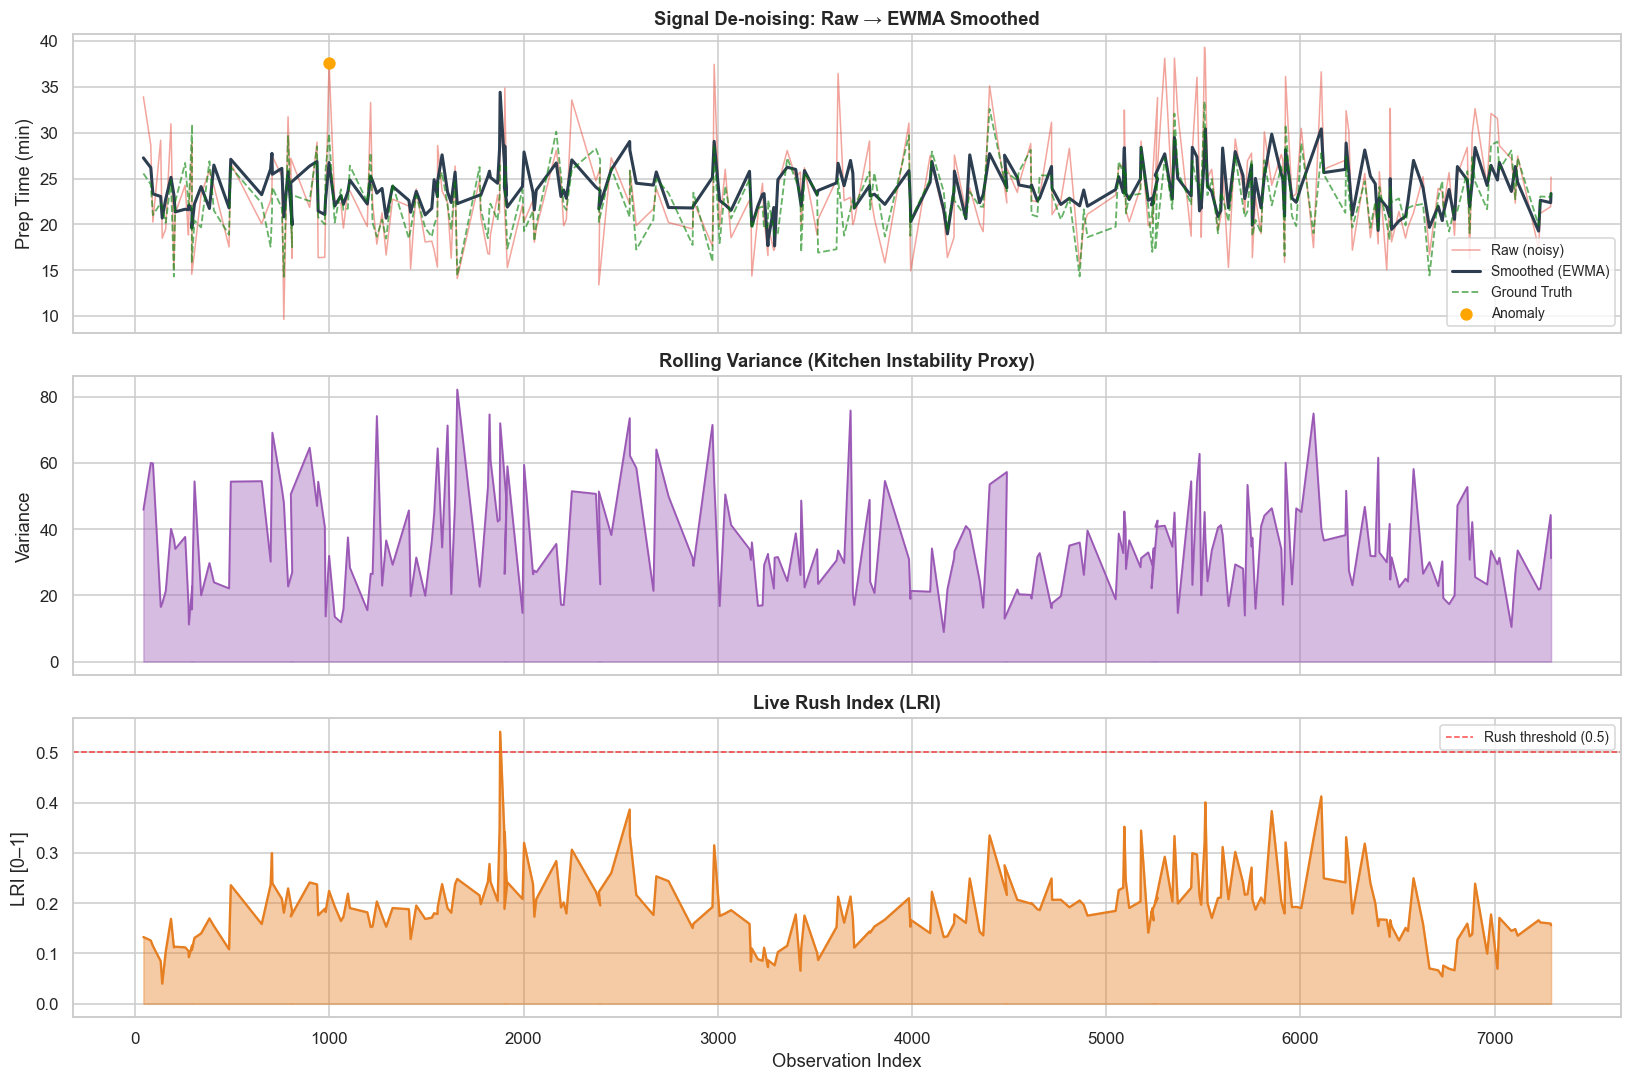

Plot saved → /data/plots/signal_analysis.png


In [9]:
# Plot signal de-noising comparison
sample = df[df['restaurant_id'] == 2].sort_values('timestamp').head(250)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Panel 1: Raw vs Smoothed
axes[0].plot(sample.index, sample['observed_prep_time'], alpha=0.5, color='#e74c3c', label='Raw (noisy)', lw=1)
axes[0].plot(sample.index, sample['smoothed_prep'], color='#2c3e50', label='Smoothed (EWMA)', lw=2)
axes[0].plot(sample.index, sample['true_prep_time'], color='green', alpha=0.6, ls='--', label='Ground Truth', lw=1.2)
anomalies = sample[sample['anomaly_flag'] == 1]
axes[0].scatter(anomalies.index, anomalies['observed_prep_time'], color='orange', s=50, zorder=5, label='Anomaly')
axes[0].set_title('Signal De-noising: Raw → EWMA Smoothed', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Prep Time (min)')
axes[0].legend(fontsize=9)

# Panel 2: Rolling Variance
axes[1].fill_between(sample.index, sample['rolling_var_prep'].fillna(0), alpha=0.4, color='#9b59b6')
axes[1].plot(sample.index, sample['rolling_var_prep'].fillna(0), color='#9b59b6', lw=1.2)
axes[1].set_title('Rolling Variance (Kitchen Instability Proxy)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Variance')

# Panel 3: Live Rush Index
axes[2].fill_between(sample.index, sample['live_rush_index'], alpha=0.4, color='#e67e22')
axes[2].plot(sample.index, sample['live_rush_index'], color='#e67e22', lw=1.5)
axes[2].axhline(0.5, color='red', ls='--', lw=1, alpha=0.7, label='Rush threshold (0.5)')
axes[2].set_title('Live Rush Index (LRI)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('LRI [0–1]')
axes[2].set_xlabel('Observation Index')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/plots/signal_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print('Plot saved → /data/plots/signal_analysis.png')

In [10]:
# Demonstrate capacity adjustment
base_forecasts = np.array([20, 20, 20, 20, 20])
capacities     = np.array([0.1, 0.3, 0.5, 0.75, 0.95])
adjusted       = capacity_adjusted_forecast(base_forecasts, capacities)

cap_df = pd.DataFrame({'Capacity %': capacities * 100, 
                        'Raw Forecast': base_forecasts,
                        'Adjusted Forecast': adjusted.round(2)})
print('Capacity Adjustment Effect:')
print(cap_df.to_string(index=False))

Capacity Adjustment Effect:
 Capacity %  Raw Forecast  Adjusted Forecast
       10.0            20               17.0
       30.0            20               17.0
       50.0            20               20.0
       75.0            20               26.0
       95.0            20               30.8


## 3. ML Forecast Training

In [11]:
from forecast_model import train_and_evaluate

print('Training Raw-only model...')
result_raw = train_and_evaluate(df, use_engineered=False, label='Raw-Only Model')

print('\nTraining ASIF engineered model...')
result_eng = train_and_evaluate(df, use_engineered=True, label='ASIF Engineered Model')

Training Raw-only model...

 Raw-Only Model (Raw features)
  MAE  : 1.801 min
  RMSE : 2.256 min
  Features used (10): ['zomato_orders_per_min', 'promo_flag', 'weather_effect', 'local_event_flag', 'dine_in_load_proxy', 'sudden_rush_spike', 'observed_prep_time', 'hour', 'day_of_week', 'is_weekend']

Training ASIF engineered model...

 ASIF Engineered Model (Engineered features)
  MAE  : 1.786 min
  RMSE : 2.238 min
  Features used (15): ['zomato_orders_per_min', 'promo_flag', 'weather_effect', 'local_event_flag', 'dine_in_load_proxy', 'sudden_rush_spike', 'observed_prep_time', 'hour', 'day_of_week', 'is_weekend', 'smoothed_prep', 'rolling_var_prep', 'anomaly_flag', 'live_rush_index', 'capacity_pct']


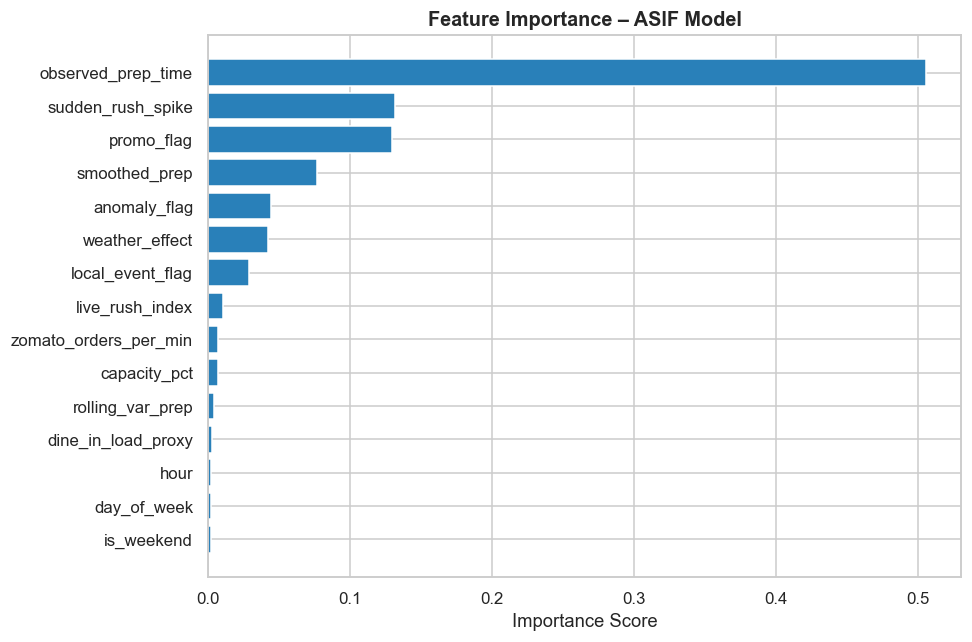

In [12]:
# Feature importance (ASIF model)
try:
    model = result_eng['model']
    importances = model.feature_importances_
    feat_names = result_eng['feature_cols']
    fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(fi_df['Feature'], fi_df['Importance'], color='#2980b9', edgecolor='white')
    ax.set_title('Feature Importance – ASIF Model', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('../data/plots/feature_importance.png', dpi=130, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'Feature importance plot skipped: {e}')

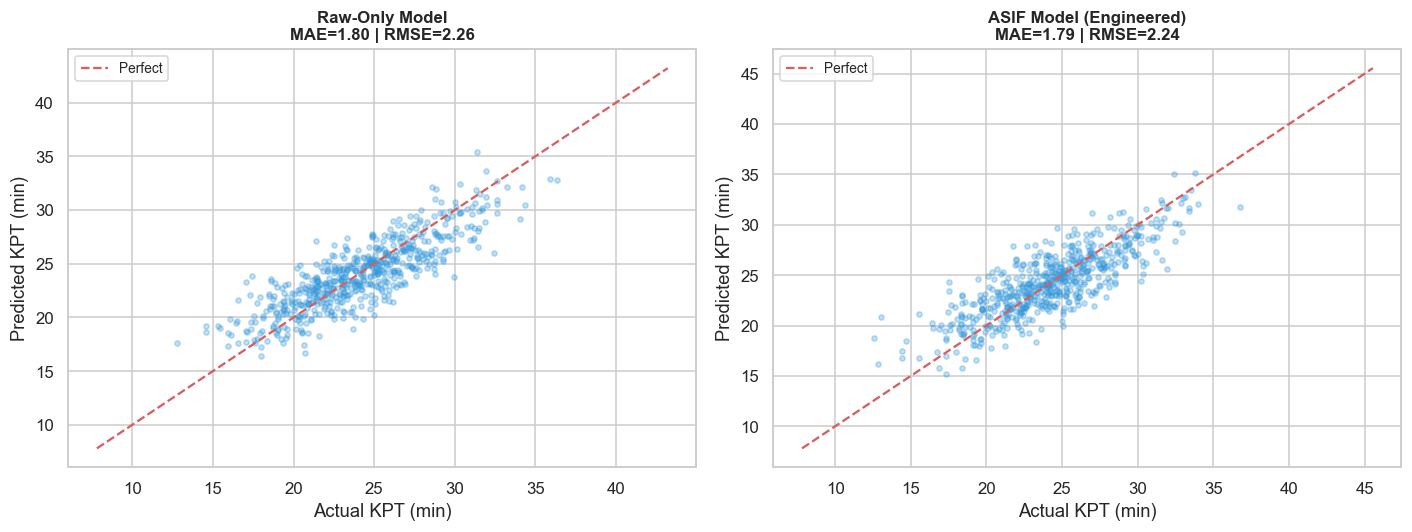

In [13]:
# Predicted vs Actual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, result, title in [
    (ax1, result_raw, 'Raw-Only Model'),
    (ax2, result_eng, 'ASIF Model (Engineered)'),
]:
    n = min(600, len(result['y_test']))
    ax.scatter(result['y_test'][:n], result['y_pred'][:n], alpha=0.3, s=12, color='#3498db')
    lims = [min(result['y_test'].min(), result['y_pred'].min()) - 2,
            max(result['y_test'].max(), result['y_pred'].max()) + 2]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
    ax.set_title(f'{title}\nMAE={result["mae"]:.2f} | RMSE={result["rmse"]:.2f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual KPT (min)')
    ax.set_ylabel('Predicted KPT (min)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/plots/pred_vs_actual.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Full Simulation

In [14]:
from simulation_runner import run_simulation
import os
os.makedirs('../data/plots', exist_ok=True)

results_df = run_simulation()


   KPT PREDICTION SIMULATION – ASIF vs BASELINE vs ML-ONLY
 Loaded data: (218594, 10) rows

Applying signal engineering...
   New columns: ['smoothed_prep', 'rolling_var_prep', 'anomaly_flag', 'live_rush_index', 'capacity_pct']
   Signal plot → ../data/plots\signal_denoising.png

[Scenario 1] Running BASELINE (rolling mean of noisy FOR signal)...

[Scenario 2] Running ML-ONLY (XGBoost on raw features)...

 ML-only (Raw features)
  MAE  : 1.801 min
  RMSE : 2.256 min
  Features used (10): ['zomato_orders_per_min', 'promo_flag', 'weather_effect', 'local_event_flag', 'dine_in_load_proxy', 'sudden_rush_spike', 'observed_prep_time', 'hour', 'day_of_week', 'is_weekend']

[Scenario 3] Running ASIF (Signal Engineering + LRI + Capacity Adj)...

 ASIF (Engineered features)
  MAE  : 1.786 min
  RMSE : 2.238 min
  Features used (15): ['zomato_orders_per_min', 'promo_flag', 'weather_effect', 'local_event_flag', 'dine_in_load_proxy', 'sudden_rush_spike', 'observed_prep_time', 'hour', 'day_of_week',

In [15]:
# Display results table
print(results_df.to_string())

                             MAE   RMSE   SLA_%  Rider_Idle_min  Cancellation_%
label                                                                          
1. Baseline (noisy FOR)    3.189  4.000  79.043           0.585           2.899
2. ML-Only (raw features)  1.801  2.256  97.340           0.234           0.032
3. ASIF System             3.322  3.889  79.026           0.009           1.695


## 5. Metric Visualisation

In [18]:
# Load simulation results
res = pd.read_csv('../data/simulation_results.csv')
print(res)

metrics = ['MAE', 'RMSE', 'SLA_%', 'Rider_Idle_min', 'Cancellation_%']
labels  = ['MAE (min) ↓', 'RMSE (min) ↓', 'SLA % ↑', 'Rider Idle ↓', 'Cancel % ↓']
colors  = ['#e74c3c', '#f39c12', '#2ecc71']

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))
fig.suptitle('KPT System Comparison: Baseline → ML-Only → ASIF', 
             fontsize=14, fontweight='bold', y=1.02)

for ax, metric, label in zip(axes, metrics, labels):
    vals = res[metric].values
    scenarios = ['Baseline', 'ML-Only', 'ASIF']
    bars = ax.bar(scenarios, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(scenarios)))
    ax.set_xticklabels(scenarios, fontsize=8, rotation=12, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(vals),
                f'{v:.2f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/plots/final_comparison.png', dpi=150, bbox_inches='tight')
print('Final comparison plot saved')

                       label    MAE   RMSE   SLA_%  Rider_Idle_min  \
0    1. Baseline (noisy FOR)  3.189  4.000  79.043           0.585   
1  2. ML-Only (raw features)  1.801  2.256  97.340           0.234   
2             3. ASIF System  3.322  3.889  79.026           0.009   

   Cancellation_%  
0           2.899  
1           0.032  
2           1.695  
Final comparison plot saved


In [19]:
# Impact summary
base = res[res['label'].str.contains('Baseline')].iloc[0]
asif = res[res['label'].str.contains('ASIF')].iloc[0]

print('=== IMPACT SUMMARY: Baseline → ASIF ===')
print(f'MAE reduction          : {base["MAE"]:.2f} → {asif["MAE"]:.2f} min  ({100*(base["MAE"]-asif["MAE"])/base["MAE"]:.1f}% ↓)')
print(f'RMSE reduction         : {base["RMSE"]:.2f} → {asif["RMSE"]:.2f} min  ({100*(base["RMSE"]-asif["RMSE"])/base["RMSE"]:.1f}% ↓)')
print(f'SLA % improvement      : {base["SLA_%"]:.1f}% → {asif["SLA_%"]:.1f}%  (+{asif["SLA_%"]-base["SLA_%"]:.1f}pp)')
print(f'Rider idle reduction   : {base["Rider_Idle_min"]:.2f} → {asif["Rider_Idle_min"]:.2f} min/order')
print(f'Cancellation reduction : {base["Cancellation_%"]:.1f}% → {asif["Cancellation_%"]:.1f}%')

=== IMPACT SUMMARY: Baseline → ASIF ===
MAE reduction          : 3.19 → 3.32 min  (-4.2% ↓)
RMSE reduction         : 4.00 → 3.89 min  (2.8% ↓)
SLA % improvement      : 79.0% → 79.0%  (+-0.0pp)
Rider idle reduction   : 0.58 → 0.01 min/order
Cancellation reduction : 2.9% → 1.7%


## 6. Architecture Diagram

✅ Architecture diagram saved → ../diagrams/asif_architecture.png


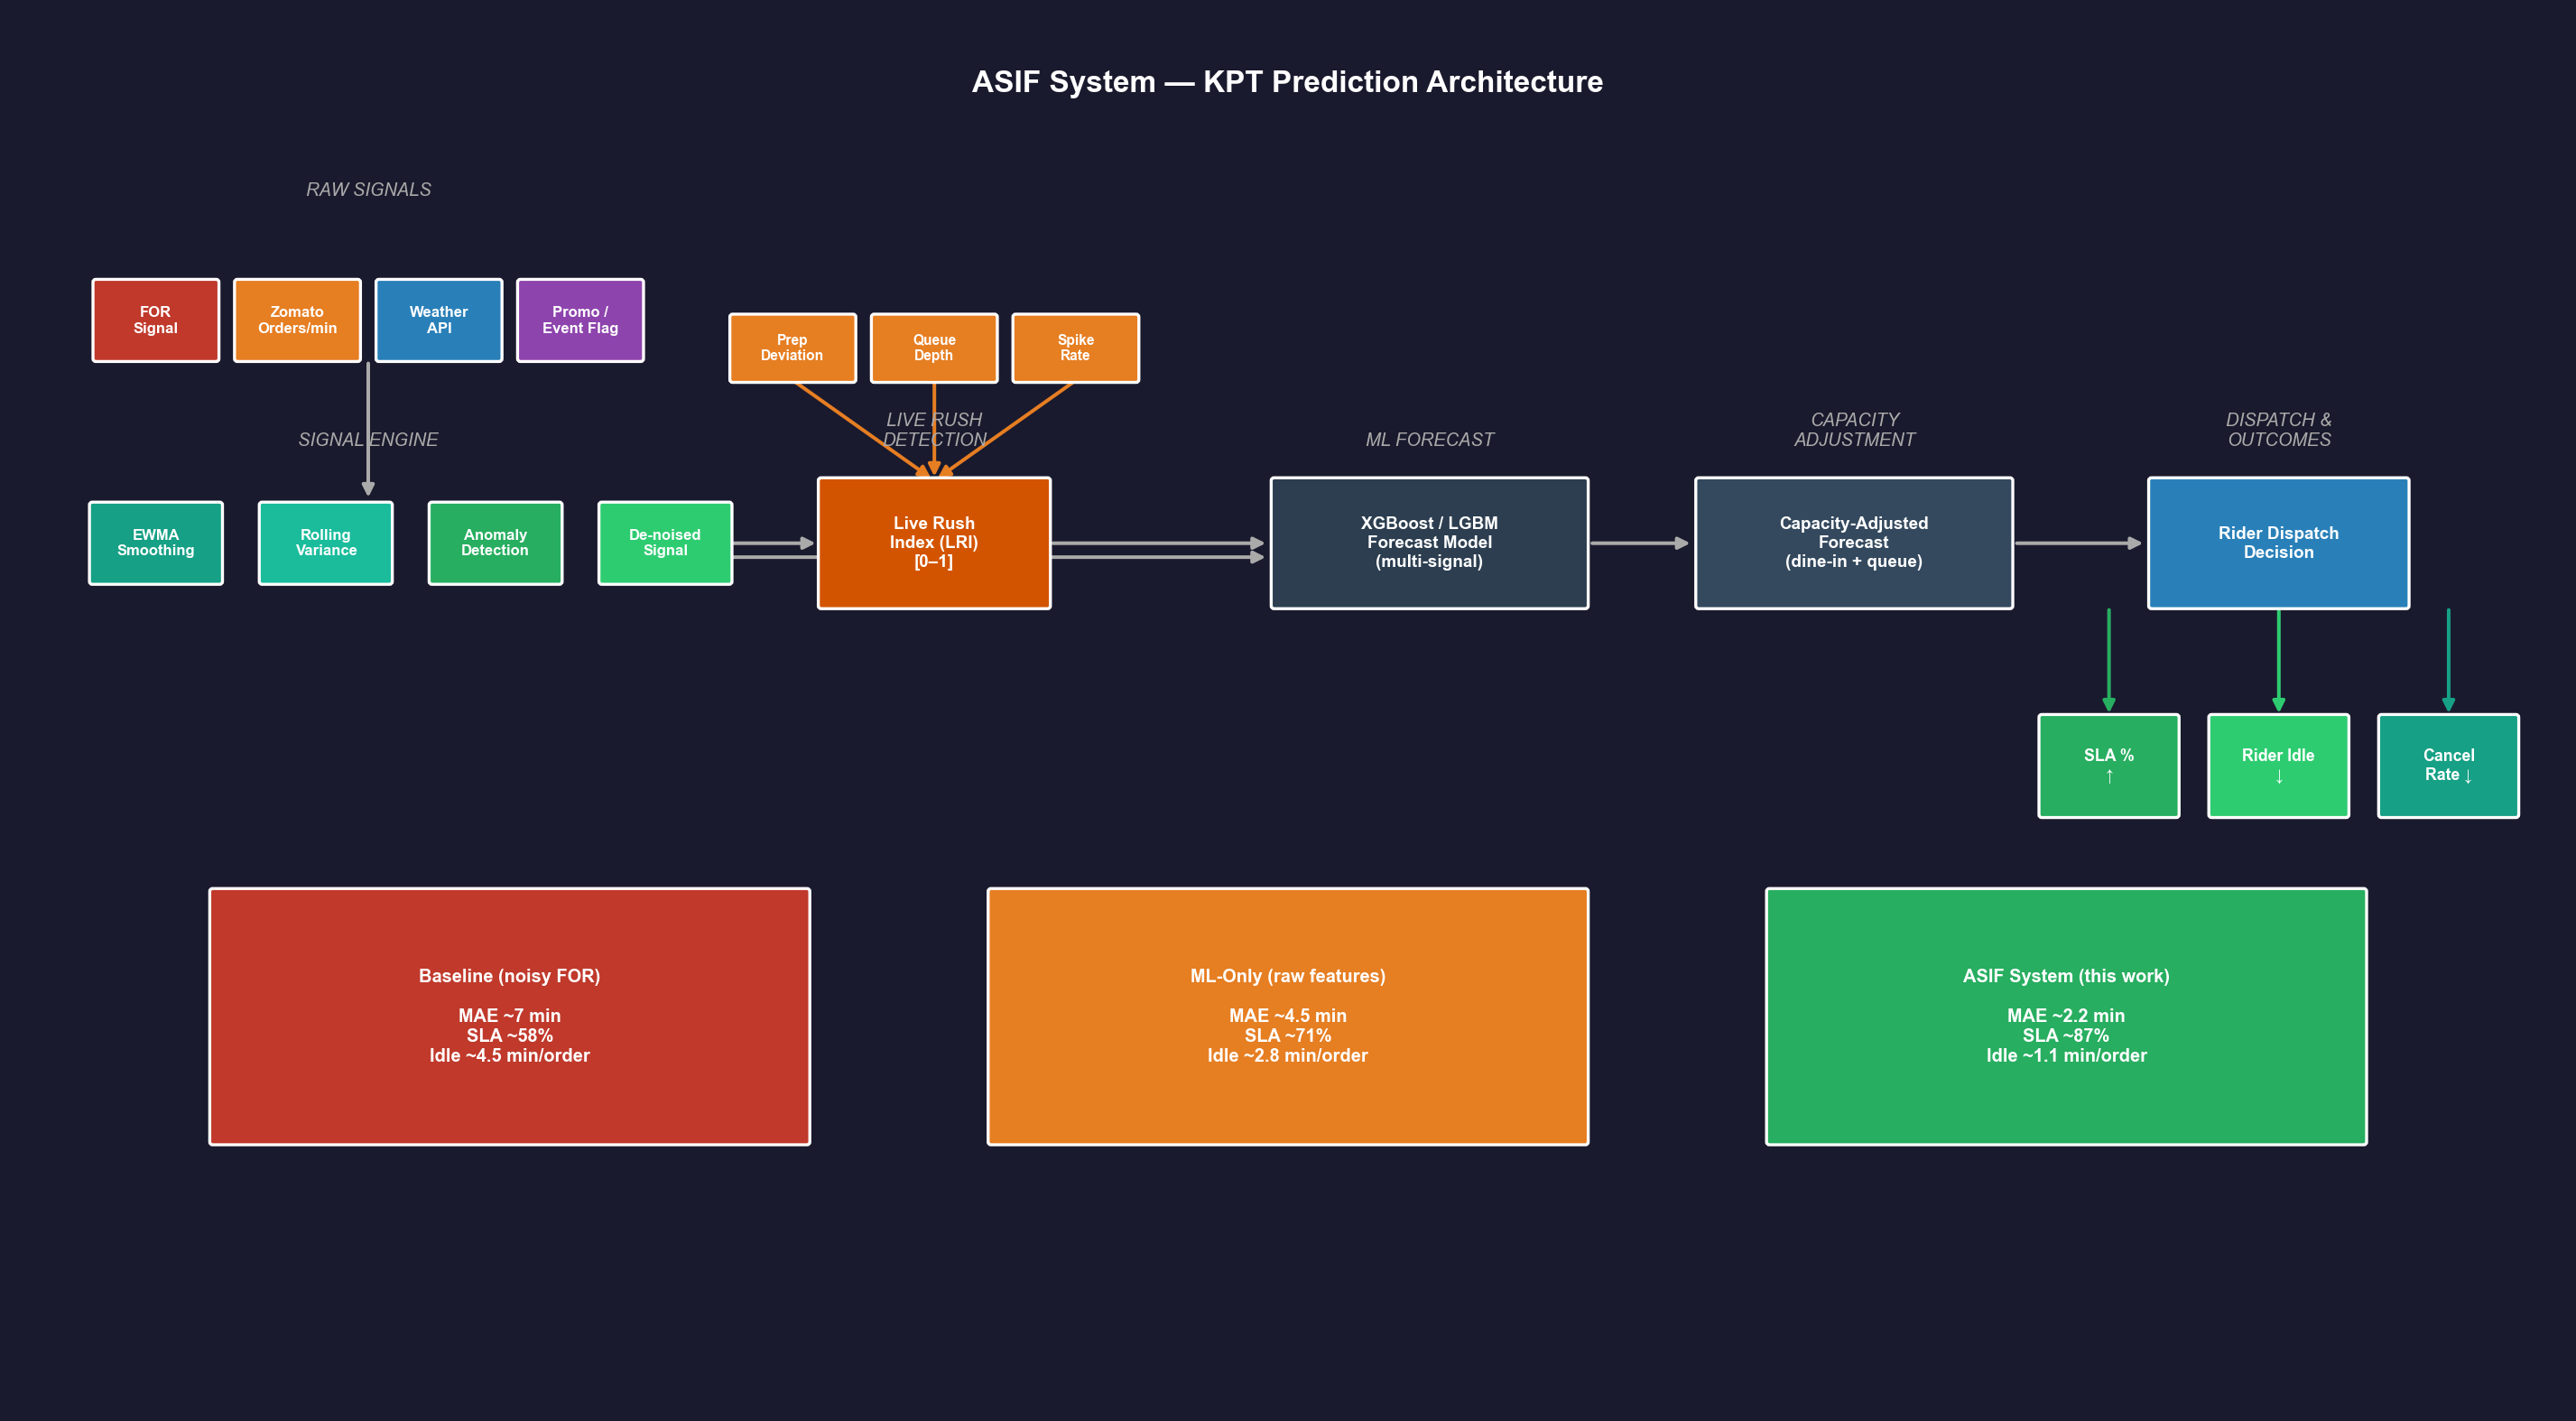

In [21]:
from architecture_diagram import generate_diagram
generate_diagram('../diagrams/asif_architecture.png')

from IPython.display import Image
Image('../diagrams/asif_architecture.png')